In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)


d:\miniconda3\envs\ai-course\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(256, input_dim=100),
        layers.LeakyReLU(0.2),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(1024),
        layers.LeakyReLU(0.2),
        layers.Dense(784, activation='tanh')
    ])
    return model


In [3]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(512, input_dim=784),
        layers.LeakyReLU(0.2),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


In [4]:
optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)

discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])

generator = build_generator()

z = layers.Input(shape=(100,))
img = generator(z)

discriminator.trainable = False
validity = discriminator(img)

gan = tf.keras.Model(z, validity)
gan.compile(loss='binary_crossentropy', optimizer=optimizer)


d:\miniconda3\envs\ai-course\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
epochs = 10000
batch_size = 64

for epoch in range(epochs):

    # ---------------------
    #  Train Discriminator
    # ---------------------
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    #  Train Generator
    # ---------------------
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")


d:\miniconda3\envs\ai-course\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.7319, acc: 45.31] [G loss: 0.7087]
100 [D loss: 3.6354, acc: 19.08] [G loss: 0.0248]
200 [D loss: 4.2777, acc: 18.59] [G loss: 0.0125]
300 [D loss: 4.6394, acc: 18.71] [G loss: 0.0084]
400 [D loss: 4.8929, acc: 18.66] [G loss: 0.0063]
500 [D loss: 5.0891, acc: 18.60] [G loss: 0.0050]
600 [D loss: 5.2476, acc: 18.57] [G loss: 0.0042]
700 [D loss: 5.3802, acc: 18.66] [G loss: 0.0036]
800 [D loss: 5.4933, acc: 18.62] [G loss: 0.0032]
900 [D loss: 5.5940, acc: 18.59] [G loss: 0.0028]
1000 [D loss: 5.6831, acc: 18.55] [G loss: 0.0025]
1100 [D loss: 5.7646, acc: 18.52] [G loss: 0.0023]
1200 [D loss: 5.8382, acc: 18.50] [G loss: 0.0021]
1300 [D loss: 5.9054, acc: 18.52] [G loss: 0.0019]
1400 [D loss: 5.9677, acc: 18.52] [G loss: 0.0018]
1500 [D loss: 6.0265, acc: 18.52] [G loss: 0.0017]
1600 [D loss: 6.0804, acc: 18.53] [G loss: 0.0016]
1700 [D loss: 6.1316, acc: 18.51] [G loss: 0.0015]
1800 [D loss: 6.1797, acc: 18.51] [G loss: 0.0014]
1900 [D loss: 6.2251, acc: 18.50] [G loss: 

In [6]:
import matplotlib.pyplot as plt

def sample_images(epoch):
    noise = np.random.normal(0, 1, (25, 100))
    gen_imgs = generator.predict(noise, verbose=0)

    gen_imgs = 0.5 * gen_imgs + 0.5
    gen_imgs = gen_imgs.reshape(25, 28, 28)

    fig, axs = plt.subplots(5, 5)
    cnt = 0
    for i in range(5):
        for j in range(5):
            axs[i,j].imshow(gen_imgs[cnt], cmap='gray')
            axs[i,j].axis('off')
            cnt += 1
    plt.show()


In [7]:
if epoch % 1000 == 0:
    sample_images(epoch)


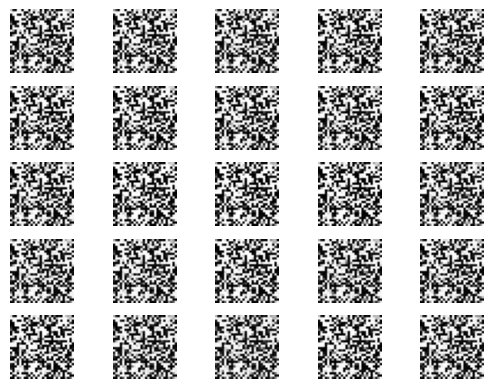

In [8]:
sample_images("final")


In [9]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5  # normalisation [-1,1]

x_train = x_train.reshape(-1, 28, 28, 1)  # IMPORTANT


In [10]:
def build_generator_cnn():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*128, input_dim=100))
    model.add(layers.Reshape((7,7,128)))

    model.add(layers.BatchNormalization())
    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(128, kernel_size=3, padding="same"))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.BatchNormalization())
    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(64, kernel_size=3, padding="same"))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Conv2D(1, kernel_size=3, padding="same", activation='tanh'))

    return model


In [11]:
def build_discriminator_cnn():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(32, kernel_size=3, strides=2,
                            padding="same",
                            input_shape=(28,28,1)))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Conv2D(64, kernel_size=3, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


In [12]:
optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)

discriminator_cnn = build_discriminator_cnn()
discriminator_cnn.compile(loss='binary_crossentropy',
                          optimizer=optimizer,
                          metrics=['accuracy'])

generator_cnn = build_generator_cnn()

z = layers.Input(shape=(100,))
img = generator_cnn(z)

discriminator_cnn.trainable = False
validity = discriminator_cnn(img)

gan_cnn = tf.keras.Model(z, validity)
gan_cnn.compile(loss='binary_crossentropy', optimizer=optimizer)


d:\miniconda3\envs\ai-course\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
epochs = 10000
batch_size = 64

for epoch in range(epochs):

    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator_cnn.predict(noise, verbose=0)

    d_loss_real = discriminator_cnn.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator_cnn.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan_cnn.train_on_batch(noise, np.ones((batch_size, 1)))

    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")


0 [D loss: 0.6921, acc: 61.33] [G loss: 0.7024]
100 [D loss: 0.7640, acc: 28.23] [G loss: 0.4135]
200 [D loss: 0.8882, acc: 27.55] [G loss: 0.3074]
300 [D loss: 1.0137, acc: 27.52] [G loss: 0.2530]
400 [D loss: 1.1131, acc: 27.54] [G loss: 0.2197]
500 [D loss: 1.1883, acc: 27.35] [G loss: 0.1969]
600 [D loss: 1.2457, acc: 27.33] [G loss: 0.1803]
700 [D loss: 1.2904, acc: 27.27] [G loss: 0.1678]
800 [D loss: 1.3260, acc: 27.31] [G loss: 0.1580]
900 [D loss: 1.3555, acc: 27.30] [G loss: 0.1500]
1000 [D loss: 1.3807, acc: 27.30] [G loss: 0.1434]
1100 [D loss: 1.4023, acc: 27.30] [G loss: 0.1378]
1200 [D loss: 1.4208, acc: 27.31] [G loss: 0.1331]
1300 [D loss: 1.4367, acc: 27.31] [G loss: 0.1290]
1400 [D loss: 1.4506, acc: 27.29] [G loss: 0.1255]
1500 [D loss: 1.4627, acc: 27.26] [G loss: 0.1224]
1600 [D loss: 1.4734, acc: 27.29] [G loss: 0.1197]
1700 [D loss: 1.4829, acc: 27.30] [G loss: 0.1173]
1800 [D loss: 1.4915, acc: 27.27] [G loss: 0.1151]
1900 [D loss: 1.4993, acc: 27.25] [G loss: 

In [14]:
def sample_images_cnn(epoch):
    noise = np.random.normal(0, 1, (25, 100))
    gen_imgs = generator_cnn.predict(noise, verbose=0)

    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axs = plt.subplots(5, 5)
    cnt = 0
    for i in range(5):
        for j in range(5):
            axs[i,j].imshow(gen_imgs[cnt,:,:,0], cmap='gray')
            axs[i,j].axis('off')
            cnt += 1
    plt.show()


In [16]:
if epoch % 1000 == 0:
    sample_images_cnn(epoch)


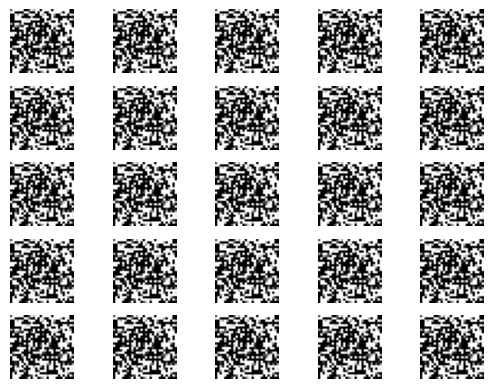

In [17]:
sample_images_cnn("final")